# ERIS - demand patterns & forecast model evaluation

This notebook explores the sales data behind ERIS and evaluates the forecasting models used in the app.
It runs against the same database as the API (the generated demo company by default) and reuses the
production code in `api/app`, so the numbers here are exactly what the application computes.

1. Demand patterns: trend, weekly and yearly seasonality, festivals, outlets
2. Model comparison from the rolling-origin back-test (`python -m app.evaluation`)
3. A hold-out forecast for one series, all models side by side

In [1]:
import sys, logging, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "api"))
warnings.filterwarnings("ignore")
logging.disable(logging.WARNING)

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from app.db import SessionLocal
from app.services import analytics as A, forecasting as F
from app.services.holidays import EVENTS

plt.rcParams.update({"figure.figsize": (10, 3.6), "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#e1e0d9", "axes.axisbelow": True})
COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
db = SessionLocal()
anchor = A.anchor_date(db)
total = F.load_series(db, F.build_spec(db, "total", None, None), anchor)
print(f"{len(total)} days of sales up to {anchor}, total revenue ₹{total.sum()/1e7:.2f} Cr")

540 days of sales up to 2026-09-30, total revenue ₹9.40 Cr


## 1. Demand patterns
### Daily revenue with a 28-day moving average

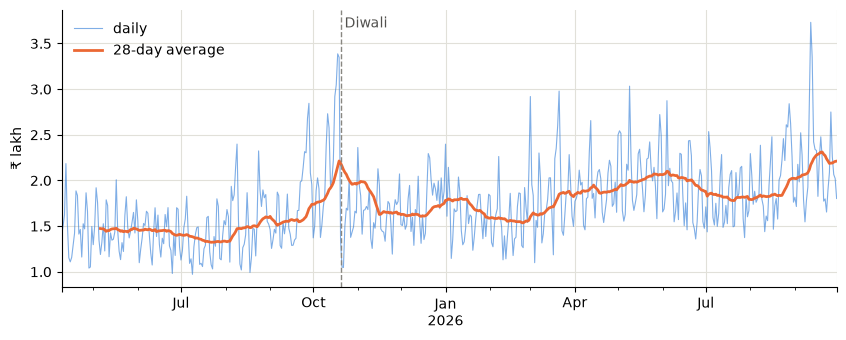

Month-on-month revenue (₹ lakh):
2025-09-01    51.4
2025-10-01    59.6
2025-11-01    50.2
2025-12-01    53.6
2026-01-01    50.6
2026-02-01    43.8
2026-03-01    57.8
2026-04-01    56.7
2026-05-01    65.4
2026-06-01    56.1
2026-07-01    55.9
2026-08-01    62.8
2026-09-01    65.5
Freq: MS


In [2]:
ax = (total / 1e5).plot(color=COLORS[0], lw=0.8, alpha=0.6, label="daily")
(total.rolling(28).mean() / 1e5).plot(ax=ax, color=COLORS[1], lw=2, label="28-day average")
for name, day, *_ in EVENTS:
    if total.index[0] <= pd.Timestamp(day) <= total.index[-1] and name == "Diwali":
        ax.axvline(pd.Timestamp(day), color="#898781", ls="--", lw=1); ax.text(pd.Timestamp(day), ax.get_ylim()[1]*0.95, " Diwali", color="#52514e")
ax.set_ylabel("₹ lakh"); ax.legend(frameon=False); plt.show()
yoy = total.resample("MS").sum()
print("Month-on-month revenue (₹ lakh):"); print((yoy / 1e5).round(1).tail(13).to_string())

### Weekly and yearly seasonality

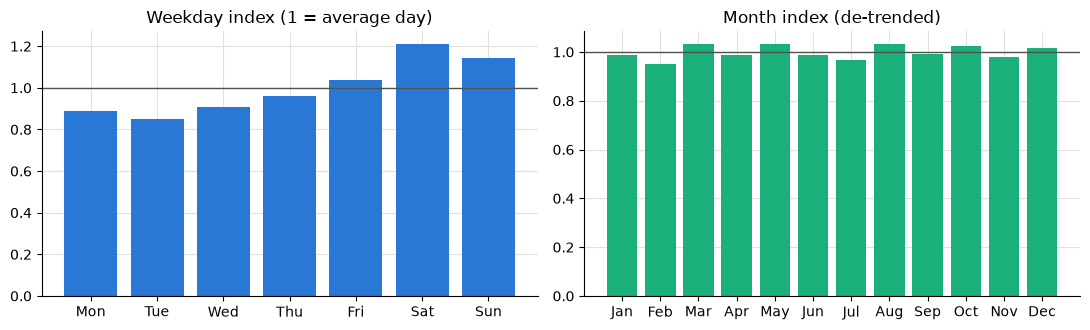

Saturday sells 42% more than Tuesday


In [3]:
fig, (a, b) = plt.subplots(1, 2, figsize=(11, 3.4))
dow = total.groupby(total.index.dayofweek).mean() / total.mean()
a.bar(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"], dow.values, color=COLORS[0]); a.axhline(1, color="#52514e", lw=1)
a.set_title("Weekday index (1 = average day)")
detr = total / total.rolling(56, center=True, min_periods=28).mean()
mon = detr.groupby(detr.index.month).mean()
b.bar([pd.Timestamp(2026, m, 1).strftime("%b") for m in mon.index], mon.values, color=COLORS[2]); b.axhline(1, color="#52514e", lw=1)
b.set_title("Month index (de-trended)"); plt.tight_layout(); plt.show()
print(f"Saturday sells {dow.iloc[5]/dow.iloc[1]-1:.0%} more than Tuesday")

### Festival effect on festive categories
Revenue of *Sweets & Festive* in the 12 days before Diwali vs other days - this is why the festival calendar is a model feature.

Average daily sweets revenue: ₹2,153 normally vs ₹7,707 before Diwali (3.6x)


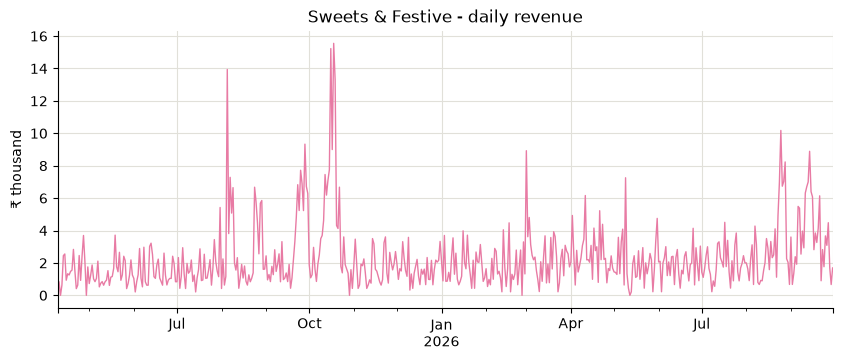

In [4]:
from app.models import Category
from sqlalchemy import select
cat = db.scalar(select(Category).where(Category.name == "Sweets & Festive"))
sweets = F.load_series(db, F.build_spec(db, "category", cat.id, None), anchor)
diwali = [pd.Timestamp(d) for n, d, *_ in EVENTS if n == "Diwali" and sweets.index[0] <= pd.Timestamp(d) <= sweets.index[-1]]
window = pd.Series(False, index=sweets.index)
for d in diwali: window[(sweets.index >= d - pd.Timedelta(days=12)) & (sweets.index <= d)] = True
print(f"Average daily sweets revenue: ₹{sweets[~window].mean():,.0f} normally vs ₹{sweets[window].mean():,.0f} before Diwali "
      f"({sweets[window].mean()/sweets[~window].mean():.1f}x)")
(sweets / 1e3).plot(color=COLORS[4], lw=1); plt.ylabel("₹ thousand"); plt.title("Sweets & Festive - daily revenue"); plt.show()

### Outlets: growth differs by location

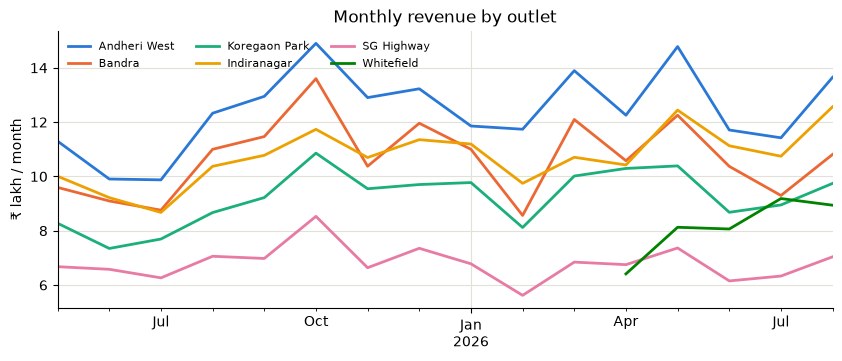

In [5]:
from app.models import Outlet
fig, ax = plt.subplots()
for i, o in enumerate(db.scalars(select(Outlet).order_by(Outlet.id))):
    s = F.load_series(db, F.build_spec(db, "outlet", o.id, None), anchor)
    (s.resample("MS").sum() / 1e5).iloc[1:-1].plot(ax=ax, color=COLORS[i], lw=2, label=o.name)
ax.set_ylabel("₹ lakh / month"); ax.legend(frameon=False, ncol=3, fontsize=8); plt.title("Monthly revenue by outlet"); plt.show()

## 2. Model comparison (rolling-origin back-test)

Results of `python -m app.evaluation`: 26 series (total, 6 outlets, 9 categories, top 10 products), 3 forecast origins
each, 28-day horizon. Each model only sees data before the origin. *ERIS auto* is the production selection rule.

In [6]:
ev = pd.read_csv(Path.cwd().parent / "docs" / "forecast_evaluation.csv")
labels = {"seasonal_naive": "Seasonal naive", "holt_winters": "Holt-Winters", "gbm": "Gradient boosting", "prophet": "Prophet", "auto": "ERIS auto"}
table = ev.pivot_table(index="model", columns="scope", values="wape", aggfunc="mean")
table["all"] = ev.groupby("model")["wape"].mean()
table = table.loc[list(labels)].rename(index=labels).round(2)
table

scope,category,outlet,product,total,all
model,,,,,
Seasonal naive,19.54,22.45,17.03,12.15,18.96
Holt-Winters,19.02,20.86,15.40,11.22,17.76
Gradient boosting,22.73,24.51,18.12,13.64,21.02
Prophet,14.52,19.93,13.93,6.99,15.25
ERIS auto,14.66,19.65,14.02,6.99,15.27


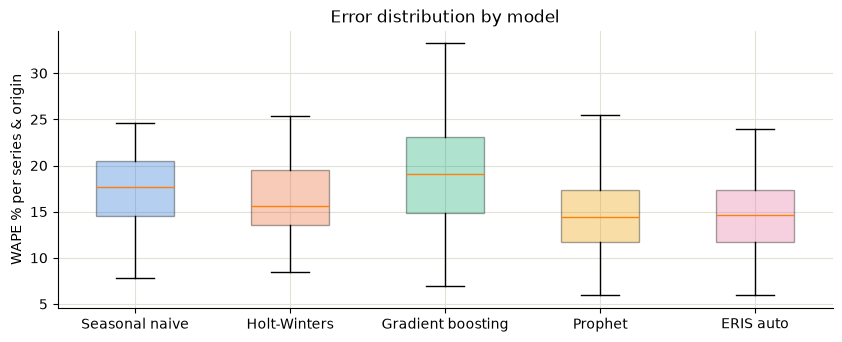

ERIS auto beats the naive baseline in 85% of 78 series/origin pairs; mean error 15.3% vs 19.0%


In [7]:
order = list(labels)
data = [ev.loc[ev.model == m, "wape"].values for m in order]
fig, ax = plt.subplots(figsize=(10, 3.6))
bp = ax.boxplot(data, tick_labels=[labels[m] for m in order], patch_artist=True, showfliers=False)
for patch, c in zip(bp["boxes"], COLORS): patch.set_facecolor(c); patch.set_alpha(0.35)
ax.set_ylabel("WAPE % per series & origin"); ax.set_title("Error distribution by model"); plt.show()
base = ev[ev.model == "seasonal_naive"].set_index(["series", "origin"])["wape"]
auto = ev[ev.model == "auto"].set_index(["series", "origin"])["wape"]
print(f"ERIS auto beats the naive baseline in {(auto < base).mean():.0%} of {len(auto)} series/origin pairs; "
      f"mean error {auto.mean():.1f}% vs {base.mean():.1f}%")

## 3. Hold-out forecast: total revenue, last 28 days
All models trained on data up to 28 days before the end, compared with what actually happened.

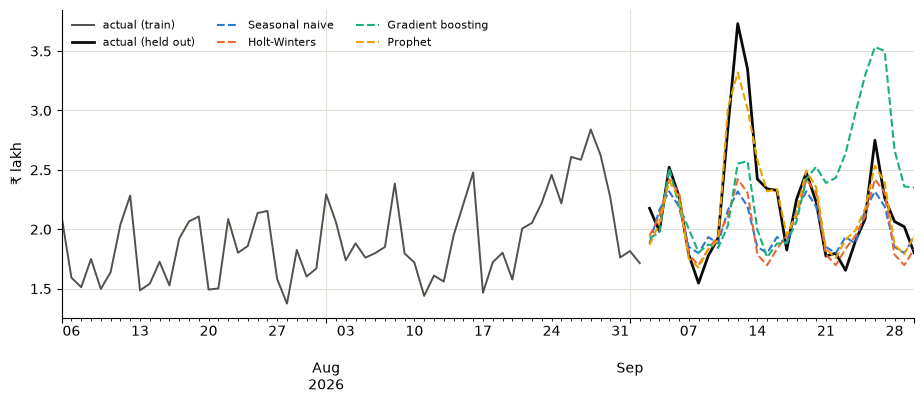

,wape,mape,mae,bias_pct
model,,,,
Seasonal naive,12.78,11.23,28275.65,-8.69
Holt-Winters,11.86,10.28,26230.76,-8.90
Gradient boosting,22.38,22.51,49504.51,6.54
Prophet,5.94,5.81,13142.80,-0.68


In [8]:
train, test = total.iloc[:-28], total.iloc[-28:]
fig, ax = plt.subplots(figsize=(11, 4))
(train.iloc[-60:] / 1e5).plot(ax=ax, color="#52514e", lw=1.4, label="actual (train)")
(test / 1e5).plot(ax=ax, color="#0b0b0b", lw=2, label="actual (held out)")
rows = []
for i, m in enumerate(F.available_models()):
    p = pd.Series(F.MODEL_FUNCS[m](train, 28), index=test.index)
    (p / 1e5).plot(ax=ax, color=COLORS[i], lw=1.5, ls="--", label=labels[m])
    rows.append({"model": labels[m], **F._metrics(test.values, p.values)})
ax.set_ylabel("₹ lakh"); ax.legend(frameon=False, ncol=3, fontsize=8); plt.show()
pd.DataFrame(rows).set_index("model")[["wape", "mape", "mae", "bias_pct"]].round(2)

## Conclusions

- Demand has a strong weekly cycle (weekends ≈ +30-40%), yearly seasonality (summer beverages, festive season)
  and large festival spikes - models that know the calendar (Prophet with holidays) win most series.
- Picking the "best" model on a single short back-test window chases noise. ERIS therefore uses two folds and keeps
  Prophet unless another model is clearly (>10%) better, which matches the best single model on average while
  adapting where a series behaves differently.
- Product-level daily series are noisy; aggregate series (outlet, category, total) are forecast far more accurately,
  which is why reorder planning adds safety stock based on demand variability.